# 3. Modelo XGBoost con Feature Engineering

Tercer modelo de clasificación binaria para predecir Heart Disease usando XGBoost con variables enriquecidas.

**Estrategia:**
1. Feature Engineering: nuevas variables clínicas derivadas de las originales
2. Modelo base con parámetros por defecto + features enriquecidas
3. Búsqueda de hiperparámetros con RandomizedSearchCV + StratifiedKFold
4. Modelo final con los mejores hiperparámetros
5. Análisis de importancia de features

**Features nuevas (4 grupos):**
- Grupo A: Indicadores clínicos derivados (HR_reserve, Double_Product, Chol_HR_ratio)
- Grupo B: Interacciones (Age×MaxHR, BP×Cholesterol, Age×STdep)
- Grupo C: Transformaciones (ST_dep_sq, ST_dep_present)
- Grupo D: Binning clínico (Age_group, BP_category, Chol_category)

**Evaluación:** ROC-AUC mediante cross-validation (5-fold)  
**Baseline (XGB Base):** ROC-AUC ~ 0.9547

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import uniform, randint
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 2. Carga de datos

In [2]:
df = pd.read_csv("../../data/train.csv")

# Target binario
df["target"] = (df["Heart Disease"] == "Presence").astype(int)

# Features originales
continuous_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
categorical_features = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
                        "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]
all_features = continuous_features + categorical_features

print(f"Shape: {df.shape}")
print(f"Target balance: {df['target'].mean():.2%} Presence")

Shape: (630000, 16)
Target balance: 44.83% Presence


## 3. Feature Engineering

Se generan variables nuevas organizadas en 4 grupos:

**Grupo A — Indicadores clínicos derivados:**
- `HR_reserve`: Max HR − Age → competencia cronotrópica (valores bajos = peor pronóstico)
- `Double_Product`: BP × Max HR → carga miocárdica de oxígeno (proxy del doble producto)
- `Chol_HR_ratio`: Cholesterol / (Max HR + 1) → relación metabólica-cardíaca

**Grupo B — Interacciones con respaldo médico:**
- `Age_x_MaxHR`: la insuficiencia cronotrópica es más significativa en pacientes mayores
- `BP_x_Chol`: el efecto combinado de hipertensión + hipercolesterolemia amplifica el riesgo CVD
- `Age_x_STdep`: cambios ST más graves en pacientes mayores (mayor carga aterosclerótica)

**Grupo C — Transformaciones no lineales:**
- `ST_dep_sq`: cuadrado de ST depression (penaliza valores altos de forma cuadrática)
- `ST_dep_present`: indicador binario de depresión ST > 0 (presencia de isquemia)

**Grupo D — Binning clínico:**
- `Age_group`: grupos de riesgo cardiovascular (<45, 45–54, 55–64, ≥65)
- `BP_category`: clasificación ACC/AHA (Normal, Elevado, Stage 1, Stage 2)
- `Chol_category`: clasificación ACC/AHA (Deseable, Límite, Alto)

In [3]:
def build_features(df):
    """Aplica feature engineering sobre un DataFrame con las features originales.
    Retorna el DataFrame con las features nuevas agregadas (no modifica el original).
    """
    X = df.copy()

    # ── Grupo A: Indicadores clínicos derivados ──────────────────────────────
    # Reserva cronotrópica: diferencia entre FC máx y edad
    # Valores negativos o muy bajos indican incompetencia cronotrópica
    X["HR_reserve"] = X["Max HR"] - X["Age"]

    # Doble producto: proxy de demanda de oxígeno miocárdico
    # Un doble producto alto durante ejercicio puede indicar mayor riesgo isquémico
    X["Double_Product"] = X["BP"] * X["Max HR"]

    # Ratio colesterol / FC máxima: relación entre carga metabólica y reserva cardíaca
    X["Chol_HR_ratio"] = X["Cholesterol"] / (X["Max HR"] + 1)

    # ── Grupo B: Interacciones ───────────────────────────────────────────────
    # Interacción edad × FC máxima: captura insuficiencia cronotrópica relativa a la edad
    X["Age_x_MaxHR"] = X["Age"] * X["Max HR"]

    # Interacción PA × Colesterol: efecto combinado de los dos principales factores de riesgo
    X["BP_x_Chol"] = X["BP"] * X["Cholesterol"]

    # Interacción edad × depresión ST: cambios isquémicos más graves en pacientes mayores
    X["Age_x_STdep"] = X["Age"] * X["ST depression"]

    # ── Grupo C: Transformaciones no lineales ────────────────────────────────
    # Cuadrado de la depresión ST: penaliza cuadráticamente los valores altos
    X["ST_dep_sq"] = X["ST depression"] ** 2

    # Indicador binario de depresión ST: presencia vs ausencia de isquemia por esfuerzo
    X["ST_dep_present"] = (X["ST depression"] > 0).astype(int)

    # ── Grupo D: Binning clínico ─────────────────────────────────────────────
    # Grupos de edad según riesgo cardiovascular (guías ESC/ACC)
    X["Age_group"] = pd.cut(
        X["Age"],
        bins=[0, 44, 54, 64, 120],
        labels=[0, 1, 2, 3]  # <45, 45-54, 55-64, ≥65
    ).astype(int)

    # Categorías de presión arterial sistólica (guías ACC/AHA 2017)
    X["BP_category"] = pd.cut(
        X["BP"],
        bins=[0, 119, 129, 139, 300],
        labels=[0, 1, 2, 3]  # Normal, Elevado, Stage 1, Stage 2
    ).astype(int)

    # Categorías de colesterol total (guías ACC/AHA)
    X["Chol_category"] = pd.cut(
        X["Cholesterol"],
        bins=[0, 199, 239, 1000],
        labels=[0, 1, 2]  # Deseable, Límite, Alto
    ).astype(int)

    return X


# Features generadas
engineered_features = [
    # Grupo A
    "HR_reserve", "Double_Product", "Chol_HR_ratio",
    # Grupo B
    "Age_x_MaxHR", "BP_x_Chol", "Age_x_STdep",
    # Grupo C
    "ST_dep_sq", "ST_dep_present",
    # Grupo D
    "Age_group", "BP_category", "Chol_category",
]

model_features = all_features + engineered_features

# Aplicar FE
df_fe = build_features(df)

y = df_fe["target"]
X = df_fe[model_features]

print(f"Features originales: {len(all_features)}")
print(f"Features nuevas:     {len(engineered_features)}")
print(f"Total features:      {len(model_features)}")
print(f"\nShape X: {X.shape}")
print(f"\nNaN por columna (nuevas features):")
print(X[engineered_features].isna().sum())

Features originales: 13
Features nuevas:     11
Total features:      24

Shape X: (630000, 24)

NaN por columna (nuevas features):
HR_reserve        0
Double_Product    0
Chol_HR_ratio     0
Age_x_MaxHR       0
BP_x_Chol         0
Age_x_STdep       0
ST_dep_sq         0
ST_dep_present    0
Age_group         0
BP_category       0
Chol_category     0
dtype: int64


In [4]:
# Estadísticas de las features nuevas
print("Estadísticas de features generadas:")
X[engineered_features].describe().round(2)

Estadísticas de features generadas:


,HR_reserve,Double_Product,Chol_HR_ratio,Age_x_MaxHR,BP_x_Chol,Age_x_STdep,ST_dep_sq,ST_dep_present,Age_group,BP_category,Chol_category
count,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.0,630000.00,630000.00,630000.00
mean,98.68,19943.45,1.62,8257.60,31971.09,39.57,1.41,0.5,1.42,1.72,1.45
std,21.55,3407.31,0.33,1568.84,5732.28,53.62,2.80,0.5,0.90,1.08,0.65
min,-6.00,6674.00,0.76,2485.00,14006.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,86.00,17640.00,1.39,7125.00,27888.00,0.00,0.00,0.0,1.00,1.00,1.00
50%,101.00,19886.00,1.57,8262.00,31590.00,3.50,0.01,1.0,1.00,2.00,2.00
75%,114.00,22200.00,1.80,9360.00,35560.00,72.00,1.96,1.0,2.00,3.00,2.00
max,173.00,37440.00,4.59,14784.00,83400.00,434.00,38.44,1.0,3.00,3.00,2.00


## 4. Modelo Base — XGBoost con FE (parámetros por defecto)

In [5]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_scores = []
base_fpr_list, base_tpr_list = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_base.fit(X_train, y_train, verbose=False)
    y_prob = xgb_base.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_prob)
    base_scores.append(auc)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    base_fpr_list.append(fpr)
    base_tpr_list.append(tpr)

    print(f"  Fold {fold}: ROC-AUC = {auc:.4f}")

print(f"\nModelo Base FE - ROC-AUC: {np.mean(base_scores):.4f} (+/- {np.std(base_scores):.4f})")
print(f"Baseline XGB (sin FE):    0.9547")
delta = np.mean(base_scores) - 0.9547
print(f"Delta vs baseline:        {delta:+.4f}")

  Fold 1: ROC-AUC = 0.9548
  Fold 2: ROC-AUC = 0.9538
  Fold 3: ROC-AUC = 0.9546
  Fold 4: ROC-AUC = 0.9543
  Fold 5: ROC-AUC = 0.9551

Modelo Base FE - ROC-AUC: 0.9545 (+/- 0.0004)
Baseline XGB (sin FE):    0.9547
Delta vs baseline:        -0.0002


## 5. Búsqueda de Hiperparámetros — RandomizedSearchCV

Misma distribución de parámetros que el modelo 2, 50 iteraciones, 5-fold StratifiedKFold.

In [6]:
param_distributions = {
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),
    "n_estimators": randint(100, 1001),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 0.5),
}

xgb_search = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)

skf_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=skf_search,
    random_state=42,
    verbose=1,
    n_jobs=1,
    return_train_score=False,
)

random_search.fit(X, y)

print(f"\nMejor ROC-AUC (CV): {random_search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor ROC-AUC (CV): nan

Mejores hiperparámetros:
  colsample_bytree: 0.749816047538945
  gamma: 0.4753571532049581
  learning_rate: 0.22227824312530747
  max_depth: 7
  min_child_weight: 5
  n_estimators: 714
  subsample: 0.7783331011414365


In [7]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results = cv_results.sort_values("rank_test_score")

top10 = cv_results[["rank_test_score", "mean_test_score", "std_test_score",
                     "param_max_depth", "param_learning_rate", "param_n_estimators",
                     "param_min_child_weight", "param_subsample",
                     "param_colsample_bytree", "param_gamma"]].head(10)

print("Top 10 configuraciones:")
print(top10.to_string(index=False))

Top 10 configuraciones:
 rank_test_score  mean_test_score  std_test_score  param_max_depth  param_learning_rate  param_n_estimators  param_min_child_weight  param_subsample  param_colsample_bytree  param_gamma
               1              NaN             NaN                7             0.222278                 714                       5         0.778333                0.749816     0.475357
               1              NaN             NaN                5             0.106775                 408                       6         0.987964                0.639990     0.229624
               1              NaN             NaN                7             0.062729                 559                       1         0.844661                0.932977     0.106170
               1              NaN             NaN                9             0.162185                 975                       3         0.805694                0.602827     0.011531
               1              NaN             

## 6. Evaluación del Mejor Modelo — Cross-Validation Detallado

In [8]:
best_params = random_search.best_params_

xgb_best = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    **best_params
)

skf_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_scores = []
best_fpr_list, best_tpr_list = [], []

for fold, (train_idx, val_idx) in enumerate(skf_eval.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_best.fit(X_train, y_train, verbose=False)
    y_prob = xgb_best.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_prob)
    best_scores.append(auc)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    best_fpr_list.append(fpr)
    best_tpr_list.append(tpr)

    print(f"  Fold {fold}: ROC-AUC = {auc:.4f}")

print(f"\nMejor Modelo FE - ROC-AUC: {np.mean(best_scores):.4f} (+/- {np.std(best_scores):.4f})")

  Fold 1: ROC-AUC = 0.9509
  Fold 2: ROC-AUC = 0.9502
  Fold 3: ROC-AUC = 0.9512
  Fold 4: ROC-AUC = 0.9507
  Fold 5: ROC-AUC = 0.9516

Mejor Modelo FE - ROC-AUC: 0.9509 (+/- 0.0005)


## 7. Curvas ROC

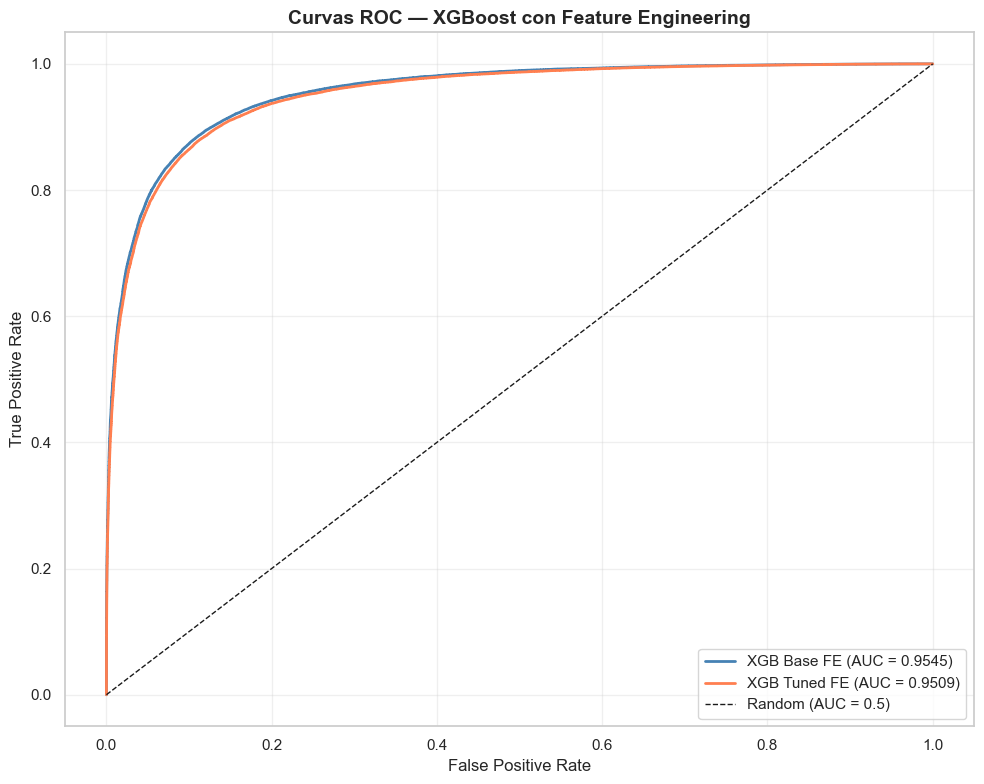

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(base_fpr_list[-1], base_tpr_list[-1], color="steelblue", linewidth=2,
        label=f"XGB Base FE (AUC = {np.mean(base_scores):.4f})")

ax.plot(best_fpr_list[-1], best_tpr_list[-1], color="coral", linewidth=2,
        label=f"XGB Tuned FE (AUC = {np.mean(best_scores):.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Curvas ROC — XGBoost con Feature Engineering", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Importancia de Features

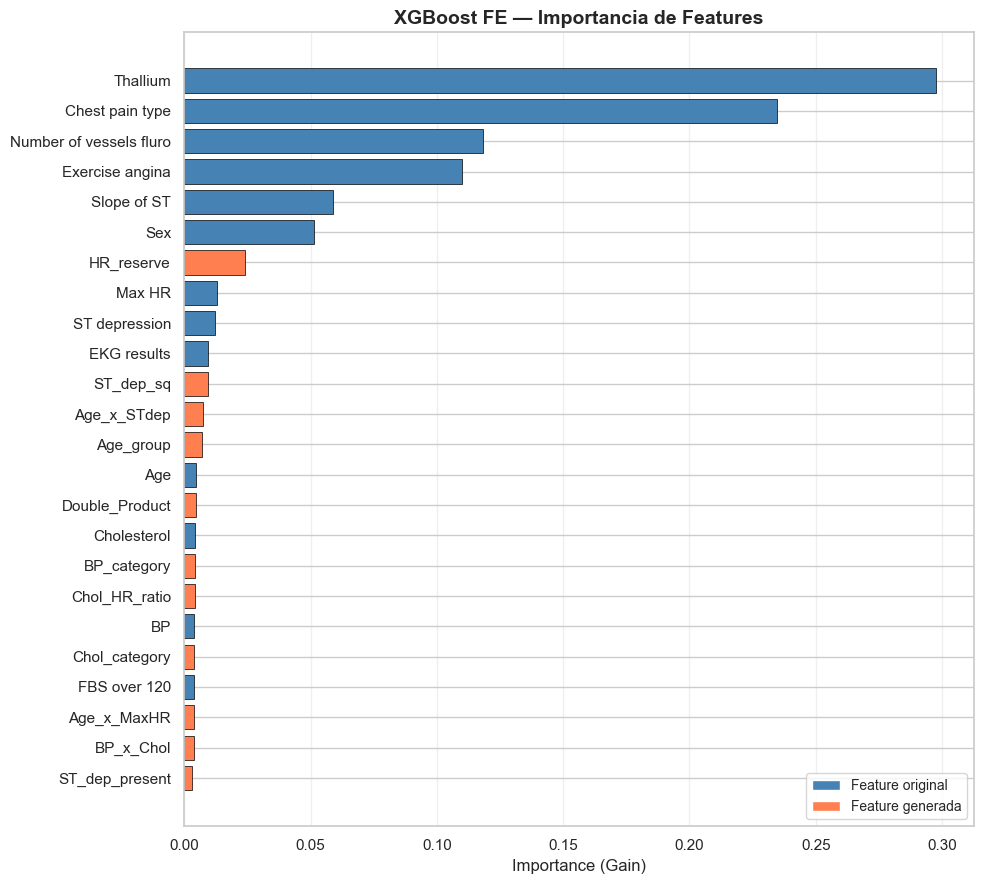


Importancia ordenada:
  Thallium                       0.2978
  Chest pain type                0.2348
  Number of vessels fluro        0.1184
  Exercise angina                0.1101
  Slope of ST                    0.0591
  Sex                            0.0515
  HR_reserve                     0.0241 [FE]
  Max HR                         0.0130
  ST depression                  0.0124
  EKG results                    0.0095
  ST_dep_sq                      0.0095 [FE]
  Age_x_STdep                    0.0075 [FE]
  Age_group                      0.0072 [FE]
  Age                            0.0048
  Double_Product                 0.0046 [FE]
  Cholesterol                    0.0044
  BP_category                    0.0043 [FE]
  Chol_HR_ratio                  0.0042 [FE]
  BP                             0.0040
  Chol_category                  0.0040 [FE]
  FBS over 120                   0.0040
  Age_x_MaxHR                    0.0039 [FE]
  BP_x_Chol                      0.0039 [FE]
  ST_de

In [10]:
xgb_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    **best_params
)
xgb_final.fit(X, y, verbose=False)

importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": xgb_final.feature_importances_,
}).sort_values("Importance", ascending=True)

# Colorear features nuevas vs originales
colors = ["coral" if f in engineered_features else "steelblue"
          for f in importance["Feature"]]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(importance["Feature"], importance["Importance"],
               color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importance (Gain)", fontsize=12)
ax.set_title("XGBoost FE — Importancia de Features", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Feature original"),
    Patch(facecolor="coral", label="Feature generada")
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")

plt.tight_layout()
plt.show()

print("\nImportancia ordenada:")
for _, row in importance.sort_values("Importance", ascending=False).iterrows():
    tag = " [FE]" if row["Feature"] in engineered_features else ""
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}{tag}")

## 9. Guardar modelo

In [11]:
model_dir = "../../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "3_xgboost_fe_best.pkl")
joblib.dump({
    "model": xgb_final,
    "best_params": best_params,
    "features": all_features,
    "engineered_features": engineered_features,
    "model_features": model_features,
    "cv_score": np.mean(best_scores),
    "cv_std": np.std(best_scores),
}, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"  ROC-AUC (CV): {np.mean(best_scores):.4f} +/- {np.std(best_scores):.4f}")
print(f"  Hiperparámetros: {best_params}")
print(f"  Features originales ({len(all_features)}): {all_features}")
print(f"  Features generadas ({len(engineered_features)}): {engineered_features}")
print(f"  Total features en modelo: {len(model_features)}")

Modelo guardado en: ../../models\3_xgboost_fe_best.pkl
  ROC-AUC (CV): 0.9509 +/- 0.0005
  Hiperparámetros: {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.22227824312530747), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 714, 'subsample': np.float64(0.7783331011414365)}
  Features originales (13): ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
  Features generadas (11): ['HR_reserve', 'Double_Product', 'Chol_HR_ratio', 'Age_x_MaxHR', 'BP_x_Chol', 'Age_x_STdep', 'ST_dep_sq', 'ST_dep_present', 'Age_group', 'BP_category', 'Chol_category']
  Total features en modelo: 24


## 10. Comparación de Modelos

In [12]:
comparison = pd.DataFrame({
    "Modelo": [
        "LR (todas, 13 vars)",
        "LR (significativas, 9 vars)",
        "XGB Base (13 vars)",
        "XGB Tuned (13 vars)",
        "XGB Base FE (24 vars)",
        "XGB Tuned FE (24 vars)",
    ],
    "N Variables": [13, 9, 13, 13, len(model_features), len(model_features)],
    "ROC-AUC Mean": [
        0.9505, 0.9485,
        0.9547, 0.9519,
        np.mean(base_scores), np.mean(best_scores)
    ],
    "ROC-AUC Std": [
        0.0003, 0.0005,
        0.0004, 0.0004,
        np.std(base_scores), np.std(best_scores)
    ],
})
comparison["ROC-AUC"] = comparison.apply(
    lambda r: f"{r['ROC-AUC Mean']:.4f} +/- {r['ROC-AUC Std']:.4f}", axis=1
)
comparison = comparison.sort_values("ROC-AUC Mean", ascending=False).reset_index(drop=True)

print("=" * 80)
print("COMPARACION DE MODELOS")
print("=" * 80)
print(comparison[["Modelo", "N Variables", "ROC-AUC"]].to_string(index=False))
print("=" * 80)

COMPARACION DE MODELOS
                     Modelo  N Variables           ROC-AUC
         XGB Base (13 vars)           13 0.9547 +/- 0.0004
      XGB Base FE (24 vars)           24 0.9545 +/- 0.0004
        XGB Tuned (13 vars)           13 0.9519 +/- 0.0004
     XGB Tuned FE (24 vars)           24 0.9509 +/- 0.0005
        LR (todas, 13 vars)           13 0.9505 +/- 0.0003
LR (significativas, 9 vars)            9 0.9485 +/- 0.0005


## 11. Resumen

**Features generadas (11 nuevas):**
- Grupo A (clínicas): `HR_reserve`, `Double_Product`, `Chol_HR_ratio`
- Grupo B (interacciones): `Age_x_MaxHR`, `BP_x_Chol`, `Age_x_STdep`
- Grupo C (transformaciones): `ST_dep_sq`, `ST_dep_present`
- Grupo D (binning): `Age_group`, `BP_category`, `Chol_category`

**Próximo paso:** Generar submission con el modelo optimizado en `notebooks/submissions/3_XGB_FE_submission.ipynb`.